In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tapakah68/segmentation-full-body-tiktok-dancing-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.82G/1.82G [00:26<00:00, 72.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tapakah68/segmentation-full-body-tiktok-dancing-dataset/versions/2


In [ ]:
!pip install -U segmentation-models-pytorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.9 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
from PIL import Image
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import pandas as pd
from sklearn.model_selection import train_test_split
from segmentation_models_pytorch.encoders import get_preprocessing_fn
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt
import cv2

In [ ]:
data = pd.read_csv(f"{path}/df.csv")
data

,Unnamed: 0,images,masks,collages
0,0,images/0_00030.png,masks/0_00030.png,collages/0_00030.jpg
1,1,images/0_00180.png,masks/0_00180.png,collages/0_00180.jpg
2,2,images/0_00330.png,masks/0_00330.png,collages/0_00330.jpg
3,3,images/0_00360.png,masks/0_00360.png,collages/0_00360.jpg
4,4,images/0_00420.png,masks/0_00420.png,collages/0_00420.jpg
...,...,...,...,...
2610,2610,images/9_00090.png,masks/9_00090.png,collages/9_00090.jpg
2611,2611,images/9_00150.png,masks/9_00150.png,collages/9_00150.jpg
2612,2612,images/9_00180.png,masks/9_00180.png,collages/9_00180.jpg
2613,2613,images/9_00240.png,masks/9_00240.png,collages/9_00240.jpg


In [ ]:
data["masks"] = f"{path}/segmentation_full_body_tik_tok_2615_img/segmentation_full_body_tik_tok_2615_img/"+data["masks"]
data["images"] = f"{path}/segmentation_full_body_tik_tok_2615_img/segmentation_full_body_tik_tok_2615_img/"+data["images"]

In [ ]:
data.head()

,Unnamed: 0,images,masks,collages
0,0,/root/.cache/kagglehub/datasets/tapakah68/segm...,/root/.cache/kagglehub/datasets/tapakah68/segm...,collages/0_00030.jpg
1,1,/root/.cache/kagglehub/datasets/tapakah68/segm...,/root/.cache/kagglehub/datasets/tapakah68/segm...,collages/0_00180.jpg
2,2,/root/.cache/kagglehub/datasets/tapakah68/segm...,/root/.cache/kagglehub/datasets/tapakah68/segm...,collages/0_00330.jpg
3,3,/root/.cache/kagglehub/datasets/tapakah68/segm...,/root/.cache/kagglehub/datasets/tapakah68/segm...,collages/0_00360.jpg
4,4,/root/.cache/kagglehub/datasets/tapakah68/segm...,/root/.cache/kagglehub/datasets/tapakah68/segm...,collages/0_00420.jpg


In [ ]:
from torchvision import transforms

In [ ]:
mask_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.PILToTensor()
])

img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(0.5,0.5)
])

In [ ]:
class SegDataSet(Dataset):

  def __init__(self, images, masks, img_transform, mask_transform):
    super().__init__()
    self.images = images
    self.masks = masks
    self.img_transform = img_transform
    self.mask_transform = mask_transform

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    img = Image.open(self.images[idx])
    mask = Image.open(self.masks[idx])
    img = self.img_transform(img)
    mask = self.mask_transform(mask)
    mask = (mask>200)[0,:,:].int()
    return img, mask


In [ ]:
x = data["images"].values
y = data["masks"].values
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.25, shuffle=True, random_state=42)

In [ ]:
ts = SegDataSet(x_train, y_train, img_transform, mask_transform)
vs = SegDataSet(x_val, y_val, img_transform, mask_transform)

In [ ]:
ts.__getitem__(0)[1].shape

torch.Size([224, 224])

In [ ]:
train_loader = DataLoader(ts, batch_size=64, shuffle=True)
val_loader = DataLoader(vs, batch_size=64, shuffle=True)

Model

In [ ]:
model = smp.UnetPlusPlus(encoder_name="resnet34", encoder_weights="imagenet", in_channels = 3, classes=1).cuda()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:

#preprocess_input = get_preprocessing_fn("resnet18", pretrained="imagenet")

In [ ]:
criterion = smp.losses.DiceLoss(mode="binary")
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:

for epoch in range():
  running_loss = 0
  model.train()
  for images, gt_masks in tqdm(train_loader):
    optimizer.zero_grad()
    predicted_mask = model(images.cuda())
    loss = criterion(predicted_mask.cpu(), gt_masks) #smp.
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  print(running_loss / len(train_loader))

100%|██████████| 31/31 [01:22<00:00,  2.65s/it]


0.5340424679940746


100%|██████████| 31/31 [01:14<00:00,  2.41s/it]


0.24021527651817567


100%|██████████| 31/31 [01:14<00:00,  2.42s/it]


0.11631040419301679


100%|██████████| 31/31 [01:18<00:00,  2.54s/it]


0.07550944243707965


100%|██████████| 31/31 [01:15<00:00,  2.43s/it]

0.05991745379663283


In [ ]:
def predict(path):
  img = Image.open(path)
  size = img.size
  img = img_transform(img).unsqueeze(0)
  model.eval()
  with torch.no_grad():
    output = model(img.cuda())
  output = output.squeeze(0, 1)
  output =  (torch.sigmoid(output)>0.5).int().cpu().numpy().astype(np.float32)
  output = cv2.resize(output, size)
  return output

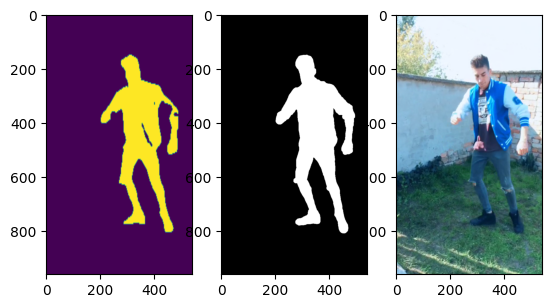

In [ ]:
idx = 80
fig, ax = plt.subplots(1, 3)
ax[0].imshow(predict(x_val[idx]))
ax[1].imshow(plt.imread(y_val[idx]))
ax[2].imshow(plt.imread(x_val[idx]))
plt.show()

In [ ]:
output = predict(x_val[idx])
orig = cv2.cvtColor(cv2.imread(x_val[idx]), cv2.COLOR_BGR2RGB)

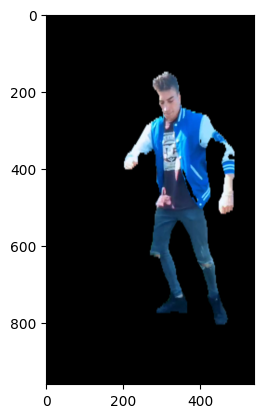

In [ ]:
plt.imshow(np.multiply(np.repeat(output[:, :, np.newaxis], 3, axis=2), orig).astype(np.int16))

In [ ]:
np.repeat(output[:, :, np.newaxis], 3, axis=2)

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], dtype=float32)